In [ ]:
import cv2
import numpy as np
from pathlib import Path

img_path = Path('/content/drive/MyDrive/flm_tem_correlation/edges_flm.png')

In [ ]:
def close_edges_flm(path):

    # Load the image in grayscale
    img = cv2.imread(path, 0)

    # 1. Close the figure
    # A 3x3 or 5x5 kernel helps bridge gaps in the lines
    kernel = np.ones((3,3), np.uint8)
    closed_edges = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel, iterations=2)

    # 2. Remove Fringe Edges
    # Find all contours in the edge map
    contours, _ = cv2.findContours(closed_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create a blank canvas for the cleaned edges
    clean_edges = np.zeros_like(img)

    # Threshold for 'fringe': filter by length (arc length) or area
    min_edge_length = 50

    for cnt in contours:
        if cv2.arcLength(cnt, False) > min_edge_length:
            cv2.drawContours(clean_edges, [cnt], -1, 255, thickness=1)

    # 3. Final 'Thinning' (Optional)
    # If closing made the lines too thick, use skeletonization or a simple erosion
    final_output = cv2.erode(clean_edges, kernel, iterations=1)

    cv2.imwrite('refined_edges_1.png', final_output)

In [ ]:
close_edges_flm(img_path)

In [ ]:
import cv2
import numpy as np

img = cv2.imread(img_path, 0)
if img is None:
    print("Error: Image not found")
else:
    # Use a small dilation just to ensure 1-pixel connectivity
    # This helps bridge gaps that are invisible to the eye but break contours
    temp_img = cv2.dilate(img, np.ones((3,3), np.uint8), iterations=1)

    contours, _ = cv2.findContours(temp_img, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)

    print(f"Total contours found: {len(contours)}")

    # Debug: Print the lengths of the top 10 contours
    lengths = [cv2.arcLength(c, False) for c in contours]
    lengths.sort(reverse=True)
    print("Top 10 contour lengths found:", lengths[:10])

Total contours found: 229
Top 10 contour lengths found: [2262.115994334221, 1670.489456295967, 1476.9280536174774, 1020.4873689413071, 508.1909055709839, 397.847758769989, 381.6345567703247, 347.1787130832672, 304.0071395635605, 284.8944422006607]


In [ ]:
# 1. Load Image
img = cv2.imread(img_path, 0)
clean_mask = np.zeros_like(img)

# 2. Get Contours (Using RETR_EXTERNAL to ignore holes/internal noise)
# We use a small dilation ONLY for connectivity during detection
temp_img = cv2.dilate(img, np.ones((3,3), np.uint8), iterations=1)
contours, _ = cv2.findContours(temp_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 3. Sort by length
# Based on your data, lengths > 250 are your "Figures"
contours = sorted(contours, key=lambda x: cv2.arcLength(x, False), reverse=True)

# 4. Join and Clean
# We take the top 10. For each, we calculate the Convex Hull to close the figure.
for i in range(min(10, len(contours))):
    cnt = contours[i]

    # This mathematically joins the gaps in your Canny output
    hull = cv2.convexHull(cnt)

    # Draw filled hulls onto the mask to create "Solid" areas for the figure
    cv2.drawContours(clean_mask, [hull], -1, 255, thickness=-1)

# 5. Intersect with original (Optional)
# If you want the EXACT original lines but only where they form the figure:
result = cv2.bitwise_and(img, img, mask=clean_mask)

# 6. Final Boundary
# If you want a smooth, closed boundary line:
final_boundary = cv2.Canny(clean_mask, 100, 200)

cv2.imwrite('closed_figures.png', clean_mask)
cv2.imwrite('refined_edges_2.png', final_boundary)

True

In [ ]:
# 1. Filter fringe first (using your known arcLength data)
contours, hierarchy = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
valid_contours = [cnt for cnt in contours if cv2.arcLength(cnt, False) > 50]

# Create a clean canvas with only the large segments
mask = np.zeros_like(img)
cv2.drawContours(mask, valid_contours, -1, 255, 1)

# 2. Bridge the gaps surgically
# Instead of a Hull, we use a Morphological CLOSE.
# This joins lines that are within 5 pixels of each other but follows the shape.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
closed = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 3. Fill the interior to ensure it's a "closed figure"
# We find contours of the 'closed' result and fill them
final_contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_mask = np.zeros_like(img)
cv2.drawContours(filled_mask, final_contours, -1, 255, thickness=-1)

# 4. Get the thin edge back
# Now that it's a solid blob, the boundary is guaranteed to be closed
result_edges = cv2.Canny(filled_mask, 100, 200)

cv2.imwrite('refined_edges_3.png', result_edges)

True

In [ ]:
# 1. Filter Fringe
# Using your previous debug data, we know the main objects are large.
# We keep everything > 50 to ensure we have the pieces needed to close the shape.
contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask = np.zeros_like(img)
for cnt in contours:
    if cv2.arcLength(cnt, False) > 50:
        cv2.drawContours(mask, [cnt], -1, 255, 1)

# 2. Bridge the Gaps (The "Join" Logic)
# We use MORPH_CLOSE. The size of the kernel (7,7) determines
# the maximum gap (in pixels) the code will jump to connect segments.
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
closed_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

# 3. Fill the Interior
# Once the lines touch, we can fill the shape to make it a solid figure.
cnts_closed, _ = cv2.findContours(closed_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filled_figure = np.zeros_like(img)
for cnt in cnts_closed:
    # Only fill the large main figures
    if cv2.contourArea(cnt) > 500:
        cv2.drawContours(filled_figure, [cnt], -1, 255, thickness=-1)

# 4. Extract Final Clean Edge
# This gives you a single-pixel, perfectly closed boundary of the figure.
final_edges = cv2.Canny(filled_figure, 100, 200)

cv2.imwrite('closed_figure_mask.png', filled_figure)
cv2.imwrite('refined_edges_4.png', final_edges)

True

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import cv2
from skimage import io

tem_path = '/content/JEY002_G3_L3_1950x_t-13.tif'
raw = io.imread(str(tem_path))
if raw.ndim == 3:
    raw = raw[:, :, 0]

# normalise to uint8 (handles uint16 TEM)
img_u8 = ((raw.astype(float) - raw.min()) / (raw.max() - raw.min() + 1e-8) * 255).astype(np.uint8)
img = 255 - img_u8

# img = cv2.imread('/content/001.png', 0)
# img = 255 - img
# img = 255 - cv2.imread('/content/Screenshot 2026-04-08 103613.png', 0)

def show_threshold(thresh):
    fig, ax = plt.subplots(figsize=(4, 4))
    thresh_img = (img > thresh).astype(np.uint8) * 255
    cv2.imwrite('thresh_img_tem.png', thresh_img)
    ax.imshow(thresh_img, cmap='gray')
    ax.set_title(f'Threshold: {thresh}')
    plt.show()

slider = widgets.IntSlider(
    min=int(img.min()),
    max=int(img.max()),
    step=int((img.max() - img.min()) / 100),
    value=int(img.max() * 0.5),
    description='Threshold'
)

widgets.interact(show_threshold, thresh=slider)

interactive(children=(IntSlider(value=127, description='Threshold', max=255, min=1, step=2), Output()), _dom_c…

<function __main__.show_threshold(thresh)>

In [ ]:
from skimage import measure
import numpy as np

binary = img > 130

labelled = measure.label(binary, connectivity=2)
props = measure.regionprops(labelled)

# sort by area, take the largest
props_sorted = sorted(props, key=lambda p: p.area, reverse=True)
largest = props_sorted[0]

# create mask of just the largest component
clean_mask = labelled == largest.label

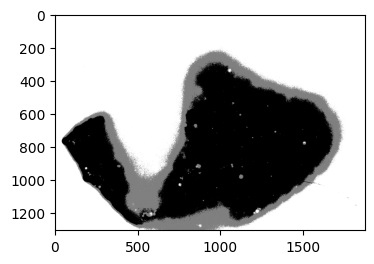

In [ ]:
img1 = 255 - cv2.imread('/content/Screenshot 2026-04-23 193757.png', 0)
img2 = cv2.imread('/content/Screenshot 2026-04-23 193757.png', 0)
# binary_high = img > 120  # tighter threshold
binary_low1 = img1 > 130   # looser threshold
binary_low2 = img2 > 50
# the difference gives you the boundary region

boundary = binary_low1.astype(int) - binary_low2.astype(int)

# from skimage.morphology import erosion, disk

# eroded = erosion(binary_low, disk(3))
# boundary = binary_low.astype(int) - eroded.astype(int)

plt.figure(figsize=(4, 4))
plt.imshow(boundary, cmap='gray')

Found 4 segments


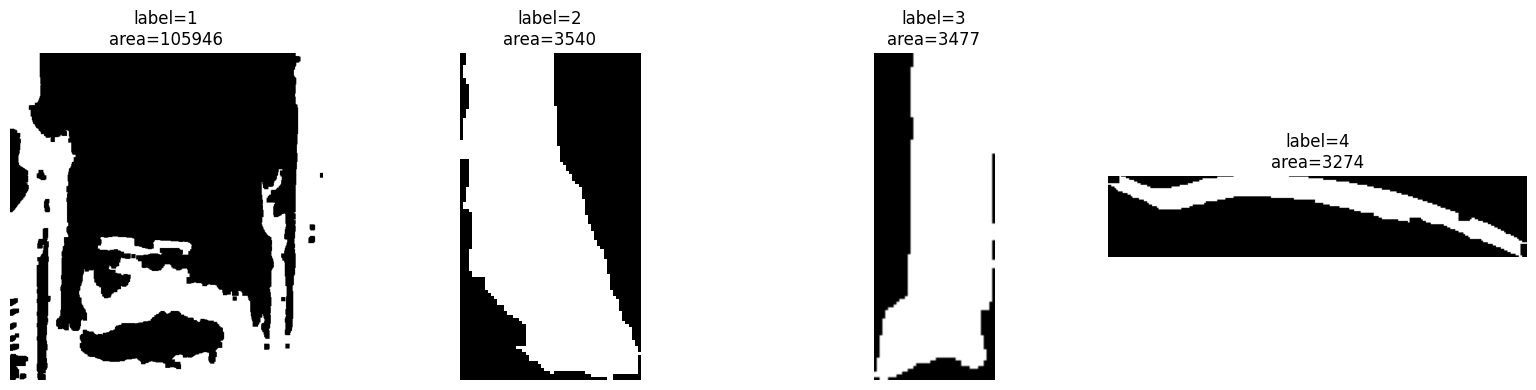

In [ ]:
img = cv2.imread("00000.png", cv2.IMREAD_GRAYSCALE)
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# optionally erode to break thin connections
kernel = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=3)

n_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(eroded)

min_area = 1000
segments = []
for label in range(1, n_labels):
    if stats[label, cv2.CC_STAT_AREA] < min_area:
        continue

    # binary mask for this component
    mask = (labels == label).astype(np.uint8) * 255

    # tight crop using bounding box from stats
    x = stats[label, cv2.CC_STAT_LEFT]
    y = stats[label, cv2.CC_STAT_TOP]
    w = stats[label, cv2.CC_STAT_WIDTH]
    h = stats[label, cv2.CC_STAT_HEIGHT]
    crop = mask[y:y+h, x:x+w]

    segments.append({
        "label":    label,
        "mask":     mask,   # full image size mask
        "crop":     crop,   # tight crop
        "bbox":     (x, y, w, h),
        "area":     stats[label, cv2.CC_STAT_AREA],
        "centroid": centroids[label],
    })

print(f"Found {len(segments)} segments")

# visualize all crops
fig, axes = plt.subplots(1, len(segments), figsize=(4 * len(segments), 4))
if len(segments) == 1:
    axes = [axes]
for ax, seg in zip(axes, segments):
    ax.imshow(seg["crop"], cmap="gray")
    ax.set_title(f"label={seg['label']}\narea={seg['area']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

True

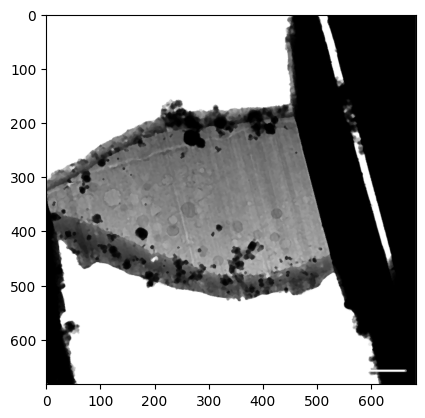

In [ ]:
import cv2
import numpy as np
from skimage import io, exposure
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_otsu, median
from skimage.morphology import disk
import matplotlib.pyplot as plt


img_path = '/content/tem.tif'
channel=0          # which channel to use
bin_factor=2        # downsampling factor
nlm_iterations=5    # non-local means iterations
median_iterations=5 # median filter iterations
min_radius=20       # circular hough min radius (in binned pixels)
max_radius=60       # circular hough max radius
canny_lo=50
canny_hi=150

img = io.imread(img_path)

# select channel
if img.ndim == 3:
    img = img[:, :, channel]
img = img.astype(np.float32)
img = (img - img.min()) / (img.max() - img.min())  # normalise to [0,1]

    # binning
if bin_factor > 1:
    h, w = img.shape
    img = cv2.resize(img, (w // bin_factor, h // bin_factor),
                        interpolation=cv2.INTER_AREA)

# non-local means denoising (iterative)
for _ in range(nlm_iterations):
    sigma = estimate_sigma(img)
    img = denoise_nl_means(img, h=1.15 * sigma, fast_mode=True,
                            patch_size=5, patch_distance=3)


img_uint8 = (img * 255).astype(np.uint8)
for _ in range(median_iterations):
    img_uint8 = cv2.medianBlur(img_uint8, 3)

#     # binarize with Otsu
# thresh = threshold_otsu(img_uint8)
# img = (img_uint8 > thresh).astype(np.uint8) * 255
plt.imshow(img_uint8, cmap='gray')
cv2.imwrite('some.png', img_uint8)

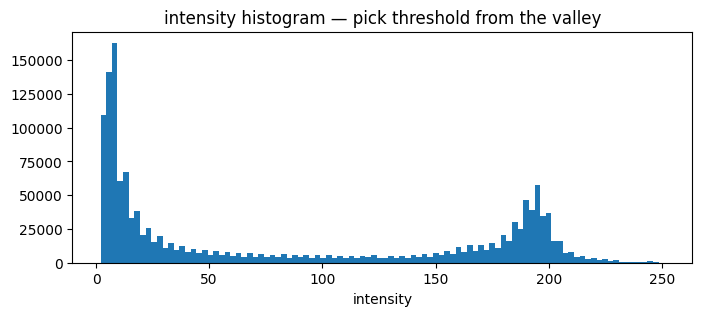

interactive(children=(IntSlider(value=128, description='threshold', max=255), Output()), _dom_classes=('widget…

<function __main__.<lambda>(threshold)>

In [ ]:
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def preview_threshold(img_uint8, threshold):
    binary = (img_uint8 > threshold).astype(np.uint8) * 255
    edges = cv2.Canny(binary, 20, 60)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_uint8, cmap='gray')
    axes[0].set_title('filtered image')
    axes[1].imshow(binary, cmap='gray')
    axes[1].set_title(f'binary @ threshold={threshold}')
    axes[2].imshow(edges, cmap='gray')
    axes[2].set_title('canny edges')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

# show histogram first to pick a starting point
plt.figure(figsize=(8, 3))
plt.hist(img_uint8.flatten(), bins=100)
plt.title('intensity histogram — pick threshold from the valley')
plt.xlabel('intensity')
plt.show()

# then interactively preview
interact(
    lambda threshold: preview_threshold(img_uint8, threshold),
    threshold=IntSlider(min=0, max=255, step=1, value=128)
)

In [ ]:
import cv2
import numpy as np
from skimage import io
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_otsu, median
from skimage.morphology import disk

def find_hole_centers(
    img_path,
    channel=0,           # which channel to use
    bin_factor=2,        # downsampling factor
    nlm_iterations=3,    # non-local means iterations
    median_iterations=3, # median filter iterations
    threshold=50,        # threshold to binarize the image
    min_radius=20,       # circular hough min radius (in binned pixels)
    max_radius=60,       # circular hough max radius
    canny_lo=50,
    canny_hi=150,
):
    img = io.imread(img_path)

    # select channel
    if img.ndim == 3:
        img = img[:, :, channel]
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min())  # normalise to [0,1]

    # # binning
    # if bin_factor > 1:
    #     h, w = img.shape
    #     img = cv2.resize(img, (w // bin_factor, h // bin_factor),
    #                      interpolation=cv2.INTER_AREA)

    # non-local means denoising (iterative)
    for _ in range(nlm_iterations):
        sigma = estimate_sigma(img)
        img = denoise_nl_means(img, h=1.15 * sigma, fast_mode=True,
                               patch_size=5, patch_distance=3)

    # median filter (iterative)
    img_uint8 = (img * 255).astype(np.uint8)
    for _ in range(median_iterations):
        img_uint8 = cv2.medianBlur(img_uint8, 3)

    binary = (img_uint8 > threshold).astype(np.uint8) * 255

    # Canny edges
    edges = cv2.Canny(binary, canny_lo, canny_hi)

    # circular Hough transform
    circles = cv2.HoughCircles(
        edges,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=min_radius * 2,   # minimum distance between centers
        param1=canny_hi,
        param2=20,                # accumulator threshold — lower = more circles
        minRadius=min_radius,
        maxRadius=max_radius,
    )

    if circles is None:
        return np.empty((0, 2))

    circles = np.round(circles[0]).astype(int)  # shape (N, 3): x, y, radius

    # scale centers back to original image coordinates
    centers = circles[:, :2] * bin_factor

    return circles, centers, img_uint8  # (N, 2) array of (x, y) in original image pixels


circles, centers, img_uint8 = find_hole_centers("/content/470Maps_sec01.tif", channel=0, bin_factor=2, threshold=205, min_radius=20, max_radius=50)
print(f"Found {len(centers)} holes")
# print(centers)

Found 47 holes


detected 47 circles


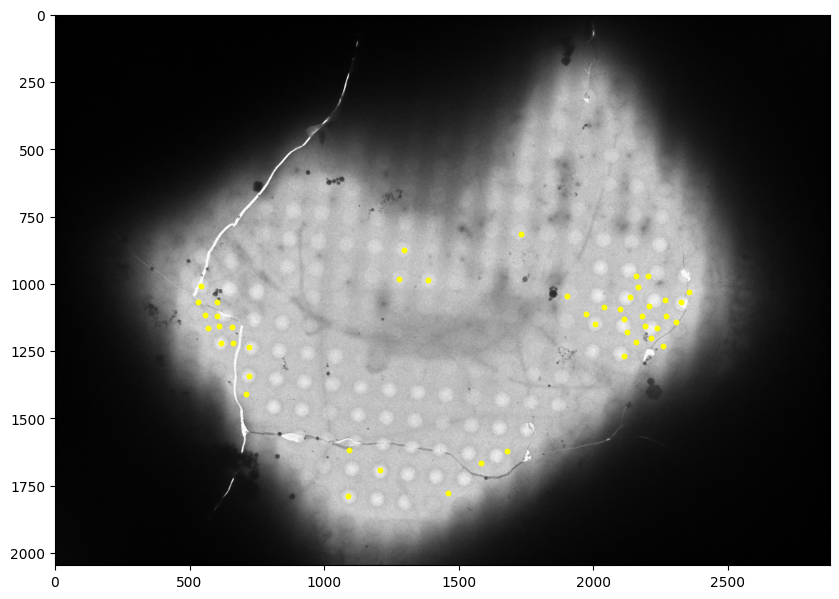

In [ ]:
print(f"detected {len(circles)} circles")
fig, ax = plt.subplots(figsize=(10,10))
ax.imshow(img_uint8, cmap='gray')
# for x, y, r in circles:
#     circle = plt.Circle((x, y), r, fill=False, color='red', linewidth=1)
#     ax.add_patch(circle)
ax.scatter(circles[:,0], circles[:,1], c='yellow', s=10)
plt.show()

Dominant grid angles: [ 45. 135.]


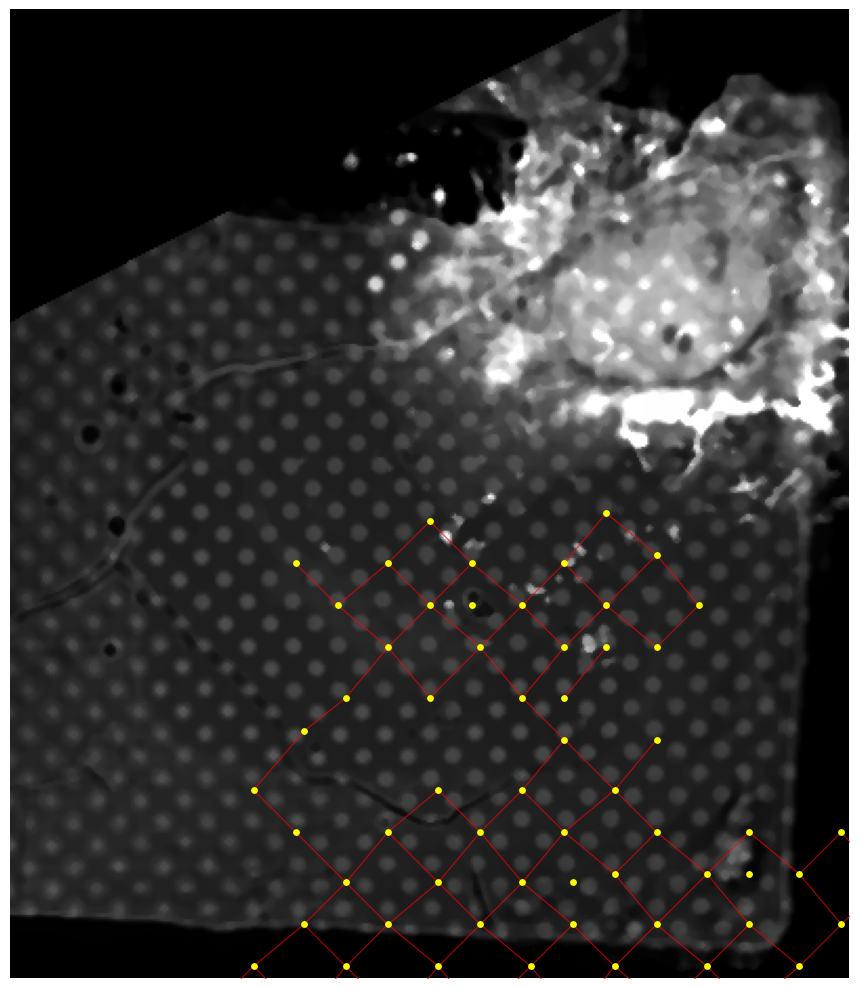

total centers: 315
valid pairs found: 1149
median spacing: 28.3px
min/max distances: 20.0 / 40.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

def draw_grid_lines(centers, img=None, angle_tol=15, figsize=(10,10)):
    tree = KDTree(centers)
    distances, indices = tree.query(centers, k=5)

    median_spacing = np.median(distances[:, 1])

    # collect all valid neighbor vectors and their angles
    all_vectors = []
    all_pairs = []
    for i, (dists, idxs) in enumerate(zip(distances, indices)):
        for d, j in zip(dists[1:], idxs[1:]):
            if d > median_spacing * 1.5:
                continue
            vec = centers[j] - centers[i]
            angle = np.degrees(np.arctan2(vec[1], vec[0])) % 180
            all_vectors.append(angle)
            all_pairs.append((i, j, d))

    all_vectors = np.array(all_vectors)

    # find two dominant angles using histogram
    hist, bin_edges = np.histogram(all_vectors, bins=180, range=(0, 180))
    # smooth histogram
    from scipy.ndimage import gaussian_filter1d
    hist_smooth = gaussian_filter1d(hist.astype(float), sigma=2)

    # find two peaks
    from scipy.signal import find_peaks
    peaks, _ = find_peaks(hist_smooth, distance=20)
    top2 = peaks[np.argsort(hist_smooth[peaks])[-2:]]
    dominant_angles = bin_edges[top2]
    print(f"Dominant grid angles: {dominant_angles}")

    # draw only connections whose angle is close to one of the two dominant axes
    h, w = img.shape[:2]

    fig, ax = plt.subplots(figsize=figsize)

    ax.set_xlim(0, w)
    ax.set_ylim(h, 0)  # inverted because image y goes top to bottom
    if img is not None:
        ax.imshow(img, cmap='gray')

    drawn = set()
    for i, j, d in all_pairs:
        pair = tuple(sorted([i, j]))
        if pair in drawn:
            continue
        vec = centers[j] - centers[i]
        angle = np.degrees(np.arctan2(vec[1], vec[0])) % 180
        # check if angle is close to either dominant axis
        close = any(min(abs(angle - a), 180 - abs(angle - a)) < angle_tol
                   for a in dominant_angles)
        if not close:
            continue
        drawn.add(pair)
        x0, y0 = centers[i]
        x1, y1 = centers[j]
        ax.plot([x0, x1], [y0, y1], 'r-', linewidth=0.8, alpha=0.7)

    ax.scatter(centers[:, 0], centers[:, 1], c='yellow', s=15, zorder=5)
    ax.set_xlim(0, img.shape[1] if img is not None else centers[:,0].max())
    ax.set_ylim(img.shape[0] if img is not None else centers[:,1].max(), 0)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"total centers: {len(centers)}")
    print(f"valid pairs found: {len(all_pairs)}")
    print(f"median spacing: {median_spacing:.1f}px")
    print(f"min/max distances: {distances[:,1].min():.1f} / {distances[:,1].max():.1f}")

draw_grid_lines(centers, img=img_uint8)

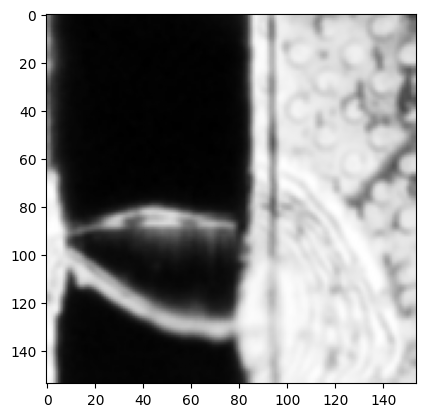

In [ ]:
import cv2
import numpy as np
from skimage import io, exposure
from skimage.restoration import denoise_nl_means, estimate_sigma
from skimage.filters import threshold_otsu, median
from skimage.morphology import disk
import matplotlib.pyplot as plt

img_path = '/content/00056.png'
channel=0          # which channel to use
bin_factor=2        # downsampling factor
nlm_iterations=3    # non-local means iterations
median_iterations=1 # median filter iterations
min_radius=20       # circular hough min radius (in binned pixels)
max_radius=60       # circular hough max radius
canny_lo=50
canny_hi=150

img = io.imread(img_path)

if len(img.shape) == 3:
    img = img[:, :, 0] # h, w, c

nlm_iterations=1    # non-local means iterations
# img = exposure.equalize_hist(img)

# non-local means denoising (iterative)
for _ in range(nlm_iterations):
    sigma = estimate_sigma(img)
    img = denoise_nl_means(img, h=0.05* sigma, fast_mode=True,
                            patch_size=1, patch_distance=1)


# img_uint8 = (img * 255).astype(np.uint8)
# for _ in range(median_iterations):
#     img_uint8 = cv2.medianBlur(img_uint8, 3)

plt.imshow(img, cmap='gray')

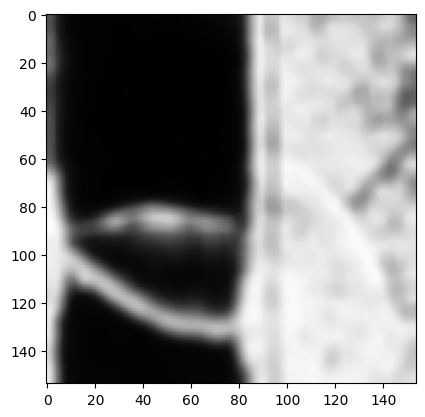

In [ ]:
from google.colab import drive
import sys
import numpy as np
drive.mount("/content/drive")
sys.path.append("/content/drive/MyDrive")
from setup_helper import load_swinir_model, swinir_upscale, download_repos_and_setup
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

download_repos_and_setup()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ All repos ready.


In [ ]:
# load the folder called filtered_bbox which contains the images for testing
drive_path = Path("/content/drive/MyDrive")
ff_bb_path = drive_path / 'filtered_bbox'
img_arr = []
for img_path in ff_bb_path.glob("*.png"):
    img = cv2.imread(img_path, 0) # open as gray scale
    img = np.stack([img] * 3, axis=-1) # need to create RGB since swinir needs to have 3 channel images
    img_arr.append(img)
img_arr[0].shape

(155, 155, 3)

In [ ]:
swinir_model = load_swinir_model()
upscaled = swinir_upscale(
    swinir_model,
    img_arr,
    window_size=8,
    max_batch_size=4
)
    # save_images_to_dir(upscaled, names, up_dir)


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


✓ SwinIR loaded from 002_lightweightSR_DIV2K_s64w8_SwinIR-S_x4.pth


In [ ]:
ff_bb_upscaled = drive_path / 'ff_bb_upscaled'
ff_bb_upscaled.mkdir(exist_ok=True)

for i, img in enumerate(upscaled):
    cv2.imwrite(ff_bb_upscaled / f'{str(i).zfill(3)}.png', img)